Se importa las librerías

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rc('image', cmap='gray')
plt.rc('figure', autolayout=True)

Se carga la imagen

Original Image Shape: (300, 300, 1)


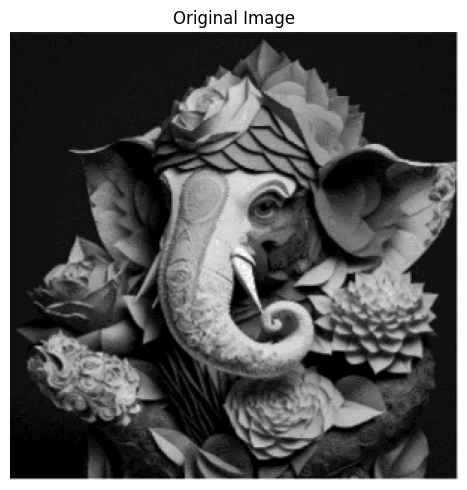

In [3]:
image_path = "imageElefante.png"

image = tf.io.read_file(image_path)
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, [300, 300])
image = tf.image.convert_image_dtype(image, tf.float32)

print("Original Image Shape:", image.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(image))
plt.title("Original Image")
plt.axis('off')
plt.show()

# Add batch dimension
image = tf.expand_dims(image, axis=0)

Se define el kernel o filtro

In [4]:
kernel = tf.constant([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=tf.float32)

kernel = tf.reshape(kernel, [3, 3, 1, 1])

Se aplica la capa convolucional

After Convolution Shape: (1, 300, 300, 1)


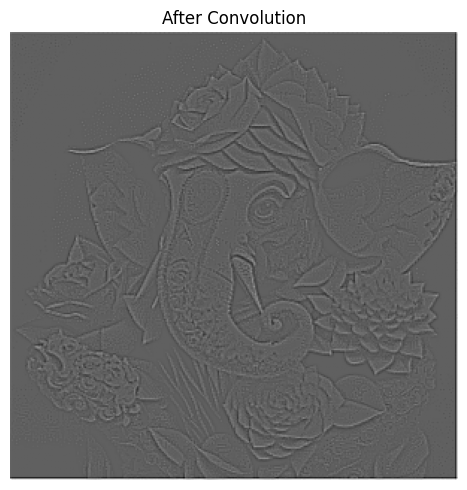

In [5]:
conv_output = tf.nn.conv2d(
    input=image,
    filters=kernel,
    strides=[1, 1, 1, 1],
    padding='SAME'
)

print("After Convolution Shape:", conv_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(conv_output))
plt.title("After Convolution")
plt.axis('off')
plt.show()

Se aplica la función de activación de ReLU

After ReLU Shape: (1, 300, 300, 1)


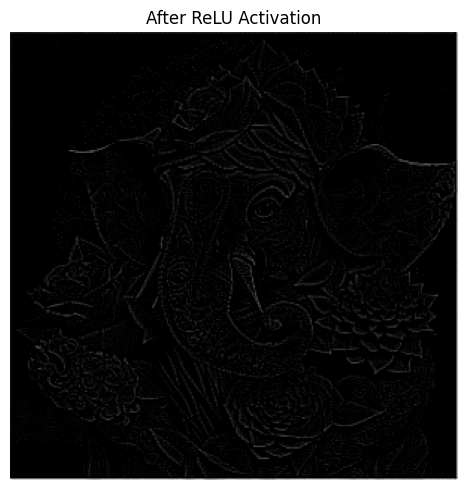

In [6]:
relu_output = tf.nn.relu(conv_output)

print("After ReLU Shape:", relu_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(relu_output))
plt.title("After ReLU Activation")
plt.axis('off')
plt.show()

Se aplica la capa de max pool

After Pooling Shape: (1, 150, 150, 1)


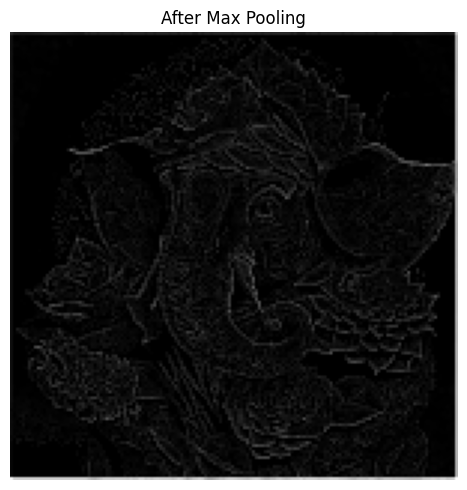

In [7]:
pool_output = tf.nn.max_pool2d(
    input=relu_output,
    ksize=[1, 2, 2, 1],
    strides=[1, 2, 2, 1],
    padding='SAME'
)

print("After Pooling Shape:", pool_output.shape)

plt.figure(figsize=(5,5))
plt.imshow(tf.squeeze(pool_output))
plt.title("After Max Pooling")
plt.axis('off')
plt.show()

Se aplica la capa de aplanamiento

In [8]:
flatten_layer = tf.keras.layers.Flatten()
flatten_output = flatten_layer(pool_output)

print("After Flatten Shape:", flatten_output.shape)

print("First 20 Flattened Values:")
print(flatten_output.numpy()[0][:20])

After Flatten Shape: (1, 22500)
First 20 Flattened Values:
[261.80835 180.35    172.83002 165.31006 157.63338 162.48999 170.00993
 177.52998 185.0502  192.57016 200.09013 207.61014 215.13016 223.12006
 224.37366 216.07034 208.55037 201.03035 193.51038 185.99039]


Se agrega una capa completamente conectada

In [9]:
dense_layer = tf.keras.layers.Dense(
    units=64,
    activation='relu'
)

dense_output = dense_layer(flatten_output)

print("After Fully Connected Layer Shape:", dense_output.shape)

After Fully Connected Layer Shape: (1, 64)
